<a href="https://colab.research.google.com/github/Reeva-17/Customer-Churn-Prediction/blob/main/notebooks/06_SVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!git clone https://github.com/Reeva-17/Customer-Churn-Prediction.git

Cloning into 'Customer-Churn-Prediction'...
remote: Enumerating objects: 94, done.
remote: Counting objects: 100% (94/94), done.
remote: Compressing objects: 100% (89/89), done.
remote: Total 94 (delta 43), reused 5 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (94/94), 1.02 MiB | 5.08 MiB/s, done.
Resolving deltas: 100% (43/43), done.


In [ ]:
%cd Customer-Churn-Prediction

/content/Customer-Churn-Prediction


In [32]:
import pandas as pd
import numpy as np


from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV,cross_val_score
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    RocCurveDisplay

)

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Load Processed Dataset
X_train = pd.read_csv("data/processed/X_train.csv")
X_test = pd.read_csv("data/processed/X_test.csv")

y_train = pd.read_csv("data/processed/y_train.csv").squeeze()
y_test = pd.read_csv("data/processed/y_test.csv").squeeze()

In [ ]:
# Verify Dataset
print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)
print("Training Labels   :", y_train.shape)
print("Testing Labels    :", y_test.shape)

Training Features : (5625, 30)
Testing Features  : (1407, 30)
Training Labels   : (5625,)
Testing Labels    : (1407,)


In [ ]:
svm = SVC(
    C=1,
    kernel="rbf",
    gamma="scale",
    probability=True,
    random_state=42
)

svm.fit(X_train, y_train)

SVC(C=1, probability=True, random_state=42)

In [ ]:
y_pred = svm.predict(X_test)

y_prob = svm.predict_proba(X_test)[:,1]

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_prob)

print("Accuracy :", accuracy)
print("Precision :", precision)
print("Recall :", recall)
print("F1 Score :", f1)
print("ROC AUC :", roc)

Accuracy : 0.7931769722814499
Precision : 0.6487455197132617
Recall : 0.4839572192513369
F1 Score : 0.554364471669219
ROC AUC : 0.7833021002117294


In [ ]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1033
           1       0.65      0.48      0.55       374

    accuracy                           0.79      1407
   macro avg       0.74      0.69      0.71      1407
weighted avg       0.78      0.79      0.78      1407



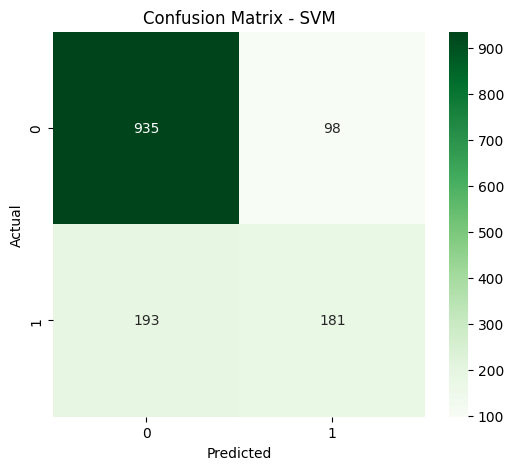

In [ ]:
# CONFUSION MATRIX

cm = confusion_matrix(y_test,y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - SVM")

plt.show()

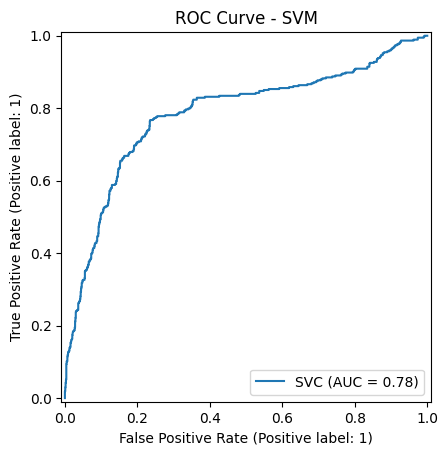

In [ ]:
# ROC CURVE
RocCurveDisplay.from_estimator(
    svm,
    X_test,
    y_test
)

plt.title("ROC Curve - SVM")

plt.show()

In [ ]:
scores = cross_val_score(
    svm,
    X_train,
    y_train,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

print("Cross Validation Scores :", scores)
print("Average F1 Score :", scores.mean())

Cross Validation Scores : [0.55769231 0.60039761 0.57587549 0.5540797  0.54901961]
Average F1 Score : 0.567412942525114


In [ ]:
param_grid = {
    "C":[0.1,1,10,50],
    "kernel":["rbf"],
    "gamma":["scale",0.1,0.01],
    "class_weight":[None,"balanced"]
}

grid = GridSearchCV(
    estimator=SVC(
        probability=True,
        random_state=42
    ),
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1

)

grid.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=SVC(probability=True, random_state=42), n_jobs=-1,
             param_grid={'C': [0.1, 1, 10, 50],
                         'class_weight': [None, 'balanced'],
                         'gamma': ['scale', 0.1, 0.01], 'kernel': ['rbf']},
             scoring='f1')

In [ ]:
print("Best Parameters :", grid.best_params_)
print("Best Cross Validation F1 :", grid.best_score_)

Best Parameters : {'C': 1, 'class_weight': 'balanced', 'gamma': 'scale', 'kernel': 'rbf'}
Best Cross Validation F1 : 0.6277210180282171


In [ ]:
best_svm = grid.best_estimator_

In [ ]:
y_pred = best_svm.predict(X_test)
y_prob = best_svm.predict_proba(X_test)[:,1]

In [ ]:
best_accuracy = accuracy_score(y_test, y_pred)
best_precision = precision_score(y_test, y_pred)
best_recall = recall_score(y_test, y_pred)
best_f1 = f1_score(y_test, y_pred)
best_roc = roc_auc_score(y_test, y_prob)

print("Accuracy :", best_accuracy)
print("Precision :", best_precision)
print("Recall :", best_recall)
print("F1 Score :", best_f1)
print("ROC AUC :", best_roc)

Accuracy : 0.7270788912579957
Precision : 0.49161073825503354
Recall : 0.7834224598930482
F1 Score : 0.6041237113402061
ROC AUC : 0.8100685403088456


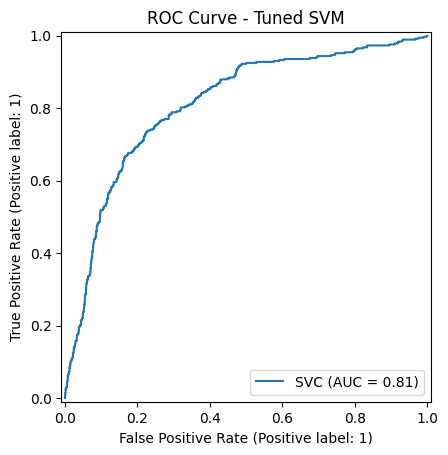

In [ ]:
# ROC CURVE AFTER TUNING


RocCurveDisplay.from_estimator(
    best_svm,
    X_test,
    y_test
)

plt.title("ROC Curve - Tuned SVM")

plt.show()

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.71      0.79      1033
           1       0.49      0.78      0.60       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.73      0.74      1407



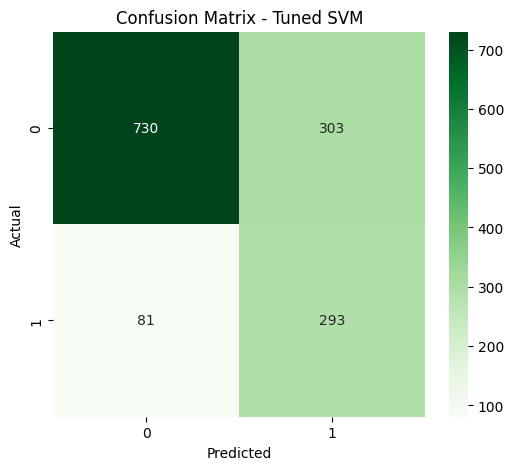

In [ ]:




cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Tuned SVM")

plt.show()

In [22]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Training predictions
train_pred = best_svm.predict(X_train)
train_prob = best_svm.predict_proba(X_train)[:,1]

# Testing predictions
test_pred = best_svm.predict(X_test)
test_prob = best_svm.predict_proba(X_test)[:,1]

print("TRAINING")
print("Accuracy :", accuracy_score(y_train, train_pred))
print("Precision:", precision_score(y_train, train_pred))
print("Recall   :", recall_score(y_train, train_pred))
print("F1 Score :", f1_score(y_train, train_pred))
print("ROC-AUC  :", roc_auc_score(y_train, train_prob))

print(" TESTING ")
print("Accuracy :", accuracy_score(y_test, test_pred))
print("Precision:", precision_score(y_test, test_pred))
print("Recall   :", recall_score(y_test, test_pred))
print("F1 Score :", f1_score(y_test, test_pred))
print("ROC-AUC  :", roc_auc_score(y_test, test_prob))

TRAINING
Accuracy : 0.7688888888888888
Precision: 0.5430844012372956
Recall   : 0.8220735785953177
F1 Score : 0.6540713145290048
ROC-AUC  : 0.8692558730878552
 TESTING 
Accuracy : 0.7270788912579957
Precision: 0.49161073825503354
Recall   : 0.7834224598930482
F1 Score : 0.6041237113402061
ROC-AUC  : 0.8100685403088456


In [30]:
import joblib
import os

joblib.dump(
    best_svm,
    "models/svm_model.pkl"
)

print("SVM model saved successfully!")

SVM model saved successfully!


In [31]:
results = pd.DataFrame({
    "Model":["Decision Tree"],
    "Accuracy":[best_accuracy],
    "Precision":[best_precision],
    "Recall":[best_recall],
    "F1 Score":[best_f1],
    "ROC-AUC":[best_roc]
})

os.makedirs("reports", exist_ok=True)

results.to_csv(
    "reports/svm_results.csv",
    index=False
)

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Decision Tree,0.727079,0.491611,0.783422,0.604124,0.810069
